In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import seaborn as sns

In [2]:
X = np.load("./data/x_train.npy")
Y = np.load("./data/y_train.npy")

X = np.hstack((X, np.ones((X.shape[0], 1))))

print(Y.shape)
print(X.shape)

(12665,)
(12665, 785)


In [18]:
def png_to_binary_array(image_path):
    """
    Converts a 28x28 PNG image to a numpy array of 0s and 1s.
    Black pixels become 0, all other pixels become 1.

    Parameters:
        image_path (str): Path to the PNG image.

    Returns:
        np.ndarray: 1D array of length 784 (28x28) with 0s and 1s.
    """
    # Open the image and convert to grayscale
    img = Image.open(image_path).convert('L')  # 'L' mode = grayscale
    
    # Convert image to numpy array
    img_array = np.array(img)
    img_array = np.append(img_array, 1)
    
    # Any pixel value greater than 0 is considered non-black
    #binary_array = np.where(img_array == 0, 0, 1)
    #binary_array = np.append(binary_array, 1)
    
    # Flatten to 1D array
    return img_array.flatten()

In [19]:
test_0 = png_to_binary_array("./data/png/binary_test_0.png")
print(test_0.shape)
test_1 = png_to_binary_array("./data/png/binary_test_1.png")
print(test_1.shape)

(785,)
(785,)


In [20]:
def sigmoid(x):
    """
    Compute the sigmoid of x, where x can be a scalar, vector, or NumPy matrix.
    
    Parameters:
        x (np.ndarray): Input array or matrix.
    
    Returns:
        np.ndarray: Sigmoid of each element in x.
    """
    return 1 / (1 + np.exp(-x))


In [21]:
def calculate_outputs(theta, X):
    """
    Calculates the activations of one layer in the neural network.

    Parameters:
        theta: Weight matrix for the layer.
        
        X: activations of previous layer.
        
    Returns:
        Matrix of dimensions theta.shape[1] by X.shape[0] with sigmoid applied to every value.
    """
    y_hat = X.dot(theta)
    out = sigmoid(y_hat)
    return out

In [22]:
def forward_prop(theta_layer1, theta_layer2, theta_layerOut, X, return_activation_array = False):
    """
    Uses the neural network to perform a forward propagation.

    Parameters:
        X: Matrix with dimensions m (number of training examples) by i (number of input features, here: 784 for all pixels).
        
        theta_layer1: matrix with dimensions i (see above, these are the weights) by f (number of neurons in the first layer).
        
        theta_layer2: matrix with dimensions f (number of neurons in the previous layer) by g (number of neurons in the second layer)
        
        theta_layerOut: matrix with dimensions g (number of neurons in previous layer) by h (number of output neurons. here: 1)

    Returns:
        single value with which probability the image represented by X shows a 1.
    """
    activations = []
    a1 = calculate_outputs(theta_layer1, X)
    a2 = calculate_outputs(theta_layer2, a1)
    out = calculate_outputs(theta_layerOut, a2)
    if(return_activation_array):
        activations.append(a1)
        activations.append(a2)
        activations.append(out)
        return out, activations
    return out

In [23]:
FIRST_LAYER_NEURONS = 3
SECOND_LAYER_NEURONS = 3

m = X.shape[0]
i = X.shape[1]

theta_1 = np.random.rand(i, FIRST_LAYER_NEURONS)
theta_2 = np.random.rand(FIRST_LAYER_NEURONS, SECOND_LAYER_NEURONS)
theta_out = np.random.rand(SECOND_LAYER_NEURONS, 1)

In [24]:
print(forward_prop(theta_1, theta_2, theta_out, X))

[[0.72541997]
 [0.72541997]
 [0.72541997]
 ...
 [0.72541997]
 [0.72541997]
 [0.72541997]]


In [25]:
def sigmoid_prime(x):
    """
    Compute the derivative of the sigmoid function.
    
    Works for scalars, vectors, or matrices (NumPy arrays).
    """
    return x * (1 - x)

In [26]:
def calculate_gradient_hidden_layer(layer_activation, theta_previous_layer, gradient_previous):
    """
    Compute the gradient for one hidden neuron layer.

    Parameters:
        layer_activation: vector which represents the neuron layers current output (after sigmoid)
        theta_previous_layer: matrix of the above layer's parameters
        gradient_previous: the result of this function for the above layer
    Returns:
        vector of slopes for each feature
    """
    delta = gradient_previous.dot(theta_previous_layer.T)
    out = delta * sigmoid_prime(layer_activation)
    return out

In [27]:
def calculate_gradient_output_layer(y_hat, Y):
    """
    Compute the gradient for the final neuron layer.

    Parameters:
        y_hat: predicted output of the network
    Returns:
        vector of slopes for each feature
    """
    delta = y_hat - Y
    out = delta * sigmoid_prime(y_hat)
    return out

In [28]:
LEARNING_RATE = 0.01
ITERATIONS = 20
J_history = np.array([0.0], dtype=float)

In [29]:
def append_to_file(path, value):
    """Append the given value to the file at the specified path."""
    with open(path, "a", encoding="utf-8") as f:
        f.write(f"{value}\n")

In [30]:
def calculate_mse(t1,t2,t3,X,Y):
    n = X.shape[0]
    y_hat = forward_prop(t1,t2,t3,X)
    delta = y_hat - Y.reshape((12665,1))
    mse = (1/n) * delta.T.dot(delta)
    return mse[0][0]

In [31]:
def back_propagation(theta_1, theta_2, theta_3, X, Y, J_history):
    for j in range(ITERATIONS):
        print("training iteration " + str(j))
        for i in range(X.shape[0]):
            y_hat, activations = forward_prop(theta_1, theta_2, theta_3, X[i], True)
            gradient_out = calculate_gradient_output_layer(y_hat, Y[i])
            gradient_2 = calculate_gradient_hidden_layer(activations[1], theta_3, gradient_out)
            gradient_1 = calculate_gradient_hidden_layer(activations[0], theta_2, gradient_2)
        
            theta_1 = theta_1 - LEARNING_RATE * gradient_1
            theta_2 = theta_2 - LEARNING_RATE * gradient_2
            theta_3 = theta_3 - LEARNING_RATE * gradient_out
        J_history = np.append(J_history, calculate_mse(theta_1,theta_2, theta_3, X, Y))
    return theta_1,theta_2,theta_3, J_history

In [32]:
print(forward_prop(theta_1, theta_2, theta_out, test_0))
print(forward_prop(theta_1, theta_2, theta_out, test_1))
calculate_mse(theta_1, theta_2, theta_out, X, Y)

## Something is wrong with the mse method

[0.72541997]
[0.72541997]


np.float64(0.286237065155239)

In [33]:
t1,t2,t3,J_history = back_propagation(theta_1, theta_2, theta_out, X, Y, J_history)

training iteration 0
training iteration 1
training iteration 2
training iteration 3
training iteration 4
training iteration 5
training iteration 6
training iteration 7
training iteration 8
training iteration 9
training iteration 10
training iteration 11
training iteration 12
training iteration 13
training iteration 14
training iteration 15
training iteration 16
training iteration 17
training iteration 18
training iteration 19


In [35]:
print(forward_prop(t1,t2,t3, test_0))
print(forward_prop(t1,t2,t3, test_1))

[0.52050224]
[0.52050224]


<Axes: >

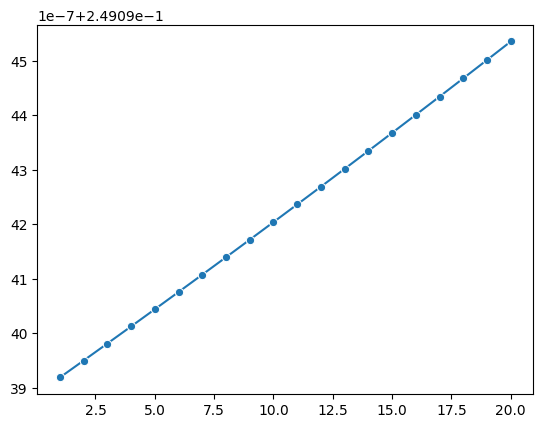

In [36]:
x = np.arange(1, ITERATIONS + 1)
J_history = np.delete(J_history, 0)
sns.lineplot(x=x, y=J_history, marker="o")

In [ ]:
print(J_history)